# 13 — Pipeline test: `110lmm50mm.fits`

Short smoke-test for the extractor pipeline on the new simulated image.

**Image facts from header:**
- Origin: `tele-img-sim`, grating mask at **23°** (`MASKANG`)
- Plate scale: ~9.9 arcsec/px (`PSARC`), FOV ~8.5° × 5.7°
- Field centre: RA 10.127°, Dec +56.537° (`RA0DEG` / `DEC0DEG`)
- 50 mm focal length, f/2 (`FOCMM`, `FNUM`)

**Goal:** confirm source detection works, try both plate-solve backends, and cross-check the recovered WCS against the known simulation ground truth.

Run from **`Python (spectrangle WSL)`** kernel for local solve-field, or any Python kernel for remote only.


## Cell 1 — Load image, inspect header, display


Image      : 110lmm50mm.fits  (3096 x 2080 px)
Origin     : tele-img-sim
Centre     : RA 10.12724°  Dec 56.53719°
Plate scale: 9.901 arcsec/px  (FOV 8.51° x 5.72°)
Rotation   : 0.00°
Mask kind  : grating  angle = 23.00°  ← ground truth
Grating    : 100.0 lines/mm,  order max 1
Exposure   : 25.0 s
Units      : electron,  gain 1.0


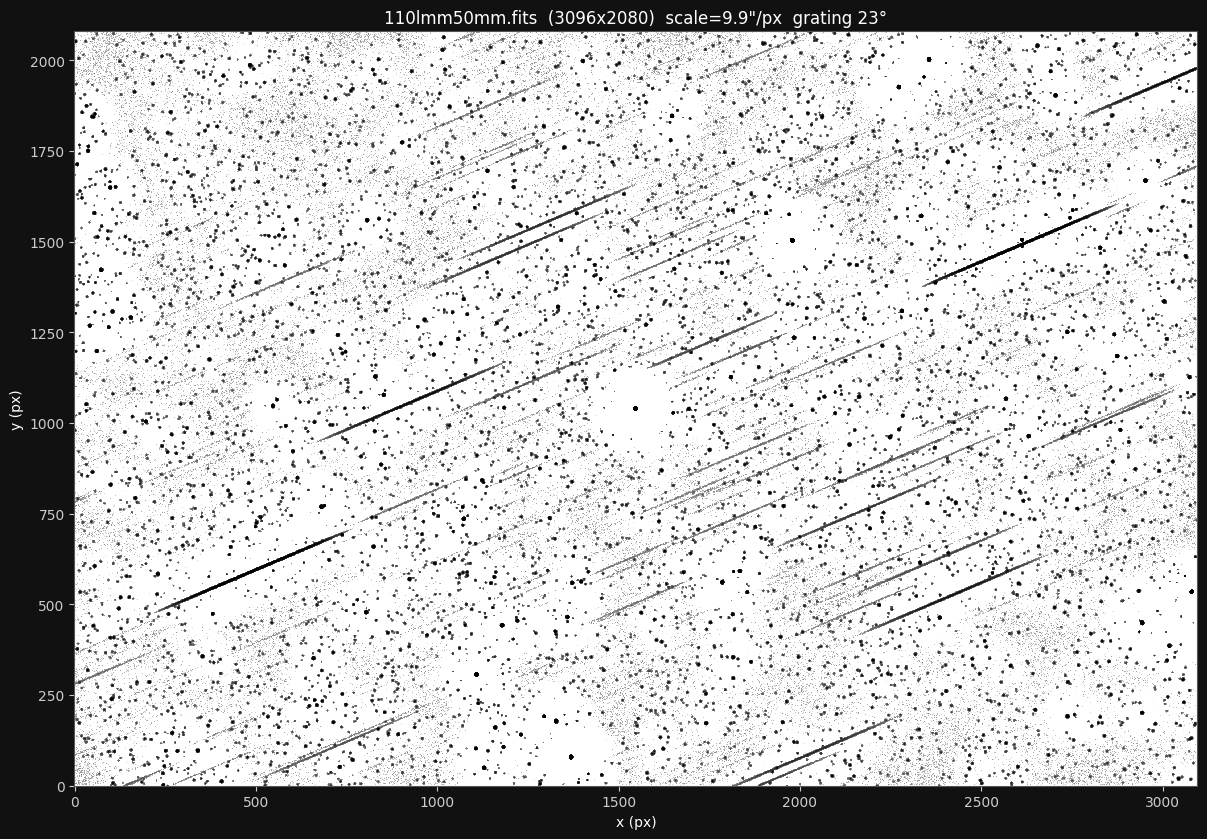

Pixel stats: min=7.8  max=717880.3  mean=67.3  std=1231.3


In [1]:
import sys, warnings, pickle, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning

_pkg_root = str(Path('..').resolve())
if _pkg_root not in sys.path:
    sys.path.insert(0, _pkg_root)

# ── Load ──────────────────────────────────────────────────────────────────────
FITS_PATH = Path('..') / 'data' / '110lmm50mm.fits'
OUT_DIR   = Path('..') / 'outputs' / '110lmm50mm_test'
OUT_DIR.mkdir(parents=True, exist_ok=True)

with fits.open(FITS_PATH) as hdul:
    image       = hdul[0].data.astype(np.float32)
    orig_header = hdul[0].header.copy()

ny, nx = image.shape

# ── Ground-truth from header ──────────────────────────────────────────────────
GT_RA_DEG    = float(orig_header.get('RA0DEG',  0.0))
GT_DEC_DEG   = float(orig_header.get('DEC0DEG', 0.0))
GT_SCALE_ARC = float(orig_header.get('PSARC',   0.0))   # arcsec/px
GT_ROT_DEG   = float(orig_header.get('ROTDEG',  0.0))   # image rotation
GT_MASK_ANG  = float(orig_header.get('MASKANG', float('nan')))  # grating angle
GT_FOV_X     = float(orig_header.get('FOVX',    0.0))   # deg
GT_FOV_Y     = float(orig_header.get('FOVY',    0.0))   # deg

print(f'Image      : {FITS_PATH.name}  ({nx} x {ny} px)')
print(f'Origin     : {orig_header.get("ORIGIN", "?")}')
print(f'Centre     : RA {GT_RA_DEG:.5f}°  Dec {GT_DEC_DEG:.5f}°')
print(f'Plate scale: {GT_SCALE_ARC:.3f} arcsec/px  (FOV {GT_FOV_X:.2f}° x {GT_FOV_Y:.2f}°)')
print(f'Rotation   : {GT_ROT_DEG:.2f}°')
print(f'Mask kind  : {orig_header.get("MASKKIND","?")}  angle = {GT_MASK_ANG:.2f}°  ← ground truth')
print(f'Grating    : {orig_header.get("GRLPMM","?")} lines/mm,  order max {orig_header.get("GROMAX","?")}')
print(f'Exposure   : {orig_header.get("EXPTIME","?")} s')
print(f'Units      : {orig_header.get("BUNIT","?")},  gain {orig_header.get("GAIN","?")}')

# ── Display ──────────────────────────────────────────────────────────────────
_bg   = gaussian_filter(image, sigma=40)
_proc = np.clip(image - _bg, 0, None)
_lo, _hi = np.percentile(_proc[np.isfinite(_proc)], [0.5, 99.7])
disp  = np.arcsinh(np.clip(_proc, _lo, _hi))
_dlo, _dhi = float(np.arcsinh(_lo)), float(np.arcsinh(_hi))

plt.rcParams.update({
    'figure.facecolor':'#111','axes.facecolor':'#111',
    'text.color':'white','axes.labelcolor':'white',
    'xtick.color':'#ccc','ytick.color':'#ccc',
    'axes.edgecolor':'#555','axes.titlecolor':'white',
    'legend.facecolor':'#1e1e1e','legend.edgecolor':'#555',
    'grid.color':'#333','grid.alpha':0.4,
    'font.size':10,'savefig.facecolor':'#111','savefig.dpi':150,
})

fig, ax = plt.subplots(figsize=(13, 8.5))
ax.imshow(disp, origin='lower', cmap='gray_r', vmin=_dlo, vmax=_dhi,
          aspect='equal', interpolation='nearest')
ax.set_title(f'{FITS_PATH.name}  ({nx}x{ny})  scale={GT_SCALE_ARC:.1f}"/px  '
             f'grating {GT_MASK_ANG:.0f}°')
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'raw_image.png', bbox_inches='tight')
plt.show()
print(f'Pixel stats: min={image.min():.1f}  max={image.max():.1f}  '
      f'mean={image.mean():.1f}  std={image.std():.1f}')


## Cell 2 — Source detection


Detected 287 sources.
Flux range: 23548.4 – 12107379.0  (median 44573.9)
Without mask_spectra: 268 sources  (delta = -19)


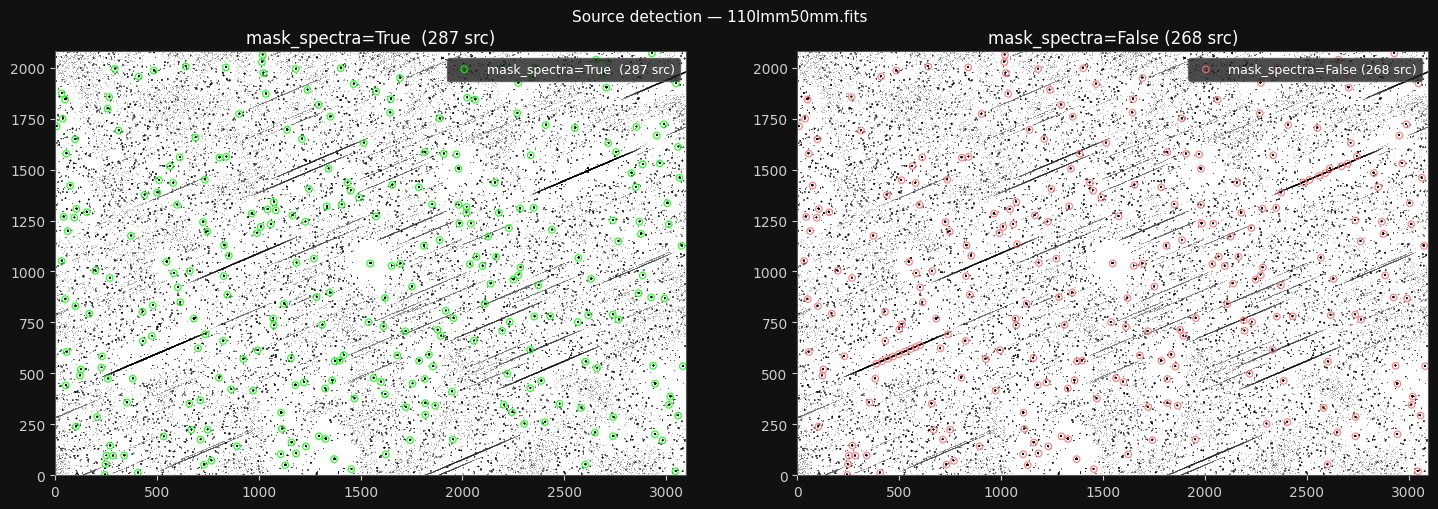

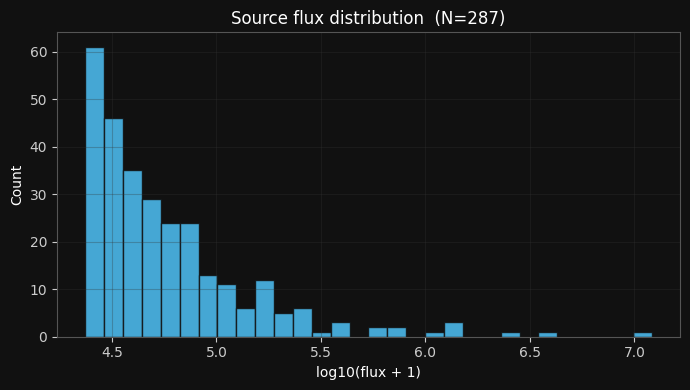

In [2]:
from extractor import extract_stars

_src_cache = OUT_DIR / 'sources.pkl'
if _src_cache.exists():
    with open(_src_cache, 'rb') as fh:
        all_xs, all_ys, all_fluxes = pickle.load(fh)
    print(f'Loaded {len(all_xs)} sources from cache.')
else:
    # mask_spectra=True suppresses the grating diffraction traces
    all_xs, all_ys, all_fluxes = extract_stars(
        image, max_sources=300, mask_spectra=True,
    )
    with open(_src_cache, 'wb') as fh:
        pickle.dump((all_xs, all_ys, all_fluxes), fh)
    print(f'Detected {len(all_xs)} sources.')

print(f'Flux range: {all_fluxes.min():.1f} – {all_fluxes.max():.1f}  (median {np.median(all_fluxes):.1f})')

# Also run without masking to see the grating traces
_no_mask_cache = OUT_DIR / 'sources_no_mask.pkl'
if _no_mask_cache.exists():
    with open(_no_mask_cache, 'rb') as fh:
        nm_xs, nm_ys, nm_fluxes = pickle.load(fh)
else:
    nm_xs, nm_ys, nm_fluxes = extract_stars(image, max_sources=300, mask_spectra=False)
    with open(_no_mask_cache, 'wb') as fh:
        pickle.dump((nm_xs, nm_ys, nm_fluxes), fh)
print(f'Without mask_spectra: {len(nm_xs)} sources  '
      f'(delta = {len(nm_xs)-len(all_xs):+d})')

# ── Plot: side-by-side with/without mask ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, _xs, _ys, _label, _col in [
    (axes[0], all_xs,  all_ys,  f'mask_spectra=True  ({len(all_xs)} src)', 'lime'),
    (axes[1], nm_xs,   nm_ys,   f'mask_spectra=False ({len(nm_xs)} src)',  '#ff6b6b'),
]:
    ax.imshow(disp, origin='lower', cmap='gray_r', vmin=_dlo, vmax=_dhi,
              aspect='equal', interpolation='nearest')
    ax.scatter(_xs, _ys, s=22, facecolors='none', edgecolors=_col,
               linewidths=0.9, alpha=0.85, label=_label)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(_label)
    ax.set_xlim(0, nx); ax.set_ylim(0, ny)

fig.suptitle(f'Source detection — {FITS_PATH.name}', fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / 'source_detection.png', bbox_inches='tight')
plt.show()

# Flux histogram
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(all_fluxes + 1), bins=30, color='#4fc3f7', edgecolor='#111', alpha=0.85)
ax.set_xlabel('log10(flux + 1)')
ax.set_ylabel('Count')
ax.set_title(f'Source flux distribution  (N={len(all_xs)})')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'flux_histogram.png', bbox_inches='tight')
plt.show()


## Cell 3 — Remote plate-solve (nova.astrometry.net)

Submits the detected source list to nova.astrometry.net.  Requires an internet connection and a valid API key in `astrometry_api.txt`.
Results are cached — re-running skips the submission.


In [3]:
from extractor.platesolve import solve_plate, wcs_summary, PlatesolveResult
from extractor.wcsangle import angle_diff_deg, center_wcs_angle_metrics

REMOTE_CACHE = OUT_DIR / 'remote_result.pkl'
REMOTE_HINTS = dict(
    center_ra=GT_RA_DEG, center_dec=GT_DEC_DEG, radius=15.0,
    scale_lower=GT_SCALE_ARC * 0.7, scale_upper=GT_SCALE_ARC * 1.4,
    scale_units='arcsecperpix',
)

def _make_wcs(header):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FITSFixedWarning)
        warnings.filterwarnings('ignore', message='.*datfix.*')
        return WCS(header)

if REMOTE_CACHE.exists():
    print('Loading remote result from cache...')
    with open(REMOTE_CACHE, 'rb') as fh:
        remote_result = pickle.load(fh)
else:
    print(f'Submitting {len(all_xs)} sources to nova.astrometry.net...')
    print(f'Hints: centre ({GT_RA_DEG:.3f}, {GT_DEC_DEG:.3f})  '
          f'scale {REMOTE_HINTS["scale_lower"]:.1f}–{REMOTE_HINTS["scale_upper"]:.1f} "/px')
    _t0 = time.time()
    try:
        remote_result = solve_plate(
            xs=all_xs, ys=all_ys,
            image_width=nx, image_height=ny,
            original_header=orig_header,
            backend='remote',
            hints=REMOTE_HINTS,
            timeout=300, verbose=True,
            fetch_products=True,
        )
        print(f'Remote solve finished in {time.time()-_t0:.0f}s')
        if remote_result is not None:
            with open(REMOTE_CACHE, 'wb') as fh:
                pickle.dump(remote_result, fh)
    except Exception as _e:
        remote_result = None
        print(f'Remote solve error: {type(_e).__name__}: {_e}')

if remote_result is None:
    print('Remote solve FAILED or skipped.')
    _remote_ok = False
else:
    _remote_ok = True
    remote_wcs = _make_wcs(remote_result.header)
    remote_m   = center_wcs_angle_metrics(remote_wcs, image.shape, compute_east=True)
    from astropy.wcs.utils import proj_plane_pixel_scales
    _rscales = proj_plane_pixel_scales(remote_wcs)
    _rps     = float(np.mean(np.abs(_rscales)) * 3600)

    print()
    print('=== Remote WCS ===')
    print(f'  Submitted      : {len(all_xs)} sources')
    print(f'  Matched        : {len(remote_result.matched_x)}')
    print(f'  Plate scale    : {_rps:.3f} arcsec/px  (GT: {GT_SCALE_ARC:.3f})')
    print(f'  Δ scale        : {_rps - GT_SCALE_ARC:+.4f} arcsec/px')
    _rctr_x, _rctr_y = remote_wcs.world_to_pixel_values(GT_RA_DEG, GT_DEC_DEG)
    print(f'  GT centre → px : ({_rctr_x:.1f}, {_rctr_y:.1f})  (expect ~{nx/2:.0f}, {ny/2:.0f})')
    print(f'  θ_north        : {remote_m.north_angle_deg:.4f}°')
    print(f'  θ_east         : {remote_m.east_angle_deg:.4f}°')
    _ne_dep = abs(angle_diff_deg(remote_m.east_angle_deg, remote_m.north_angle_deg) - 90.0)
    print(f'  N/E departure  : {_ne_dep:.4f}°')
    print()
    print(wcs_summary(remote_result.header))


Submitting 287 sources to nova.astrometry.net...
Hints: centre (10.127, 56.537)  scale 6.9–13.9 "/px
Logged in to nova.astrometry.net
Submitting 287 sources  (3096x2080 frame).
Source list uploaded (submission 15086182)
Waiting for job assignment................................................. job 15897942
Solving. solved!
WCS header fetched.
Fetching products:
  corr: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/corr_file/15897942
  corr: 20160 bytes, first 16: b'SIMPLE  =       '
  corr: HDU0=PrimaryHDU, HDU1=BinTableHDU
  corr: 102 rows | cols: ['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']
  axy: HTTP 200, Content-Type=application/fits, url=https://nova.astrometry.net/axy_file/15897942
  axy: 11520 bytes, first 16: b'SIMPLE  =       '
  axy: HDU0=PrimaryHDU, HDU1=BinTableHDU
  axy: 287 rows | cols: ['X', 'Y']
  rdls: HTTP 200, Con

## Cell 4 — Local plate-solve (solve-field, WSL)

Uses the local `solve-field` binary.  Switch to the `Python (spectrangle WSL)` kernel if this cell fails.
Scale bounds 8–12 arcsec/px match the simulated image.


In [4]:
import shutil
from extractor.platesolve import LocalSolveFieldError

BACKEND_CFG  = '/mnt/c/Users/bassd/.astrometry/backend.cfg'
INDEX_DIR    = Path('/mnt/c/Users/bassd/astrometry-data/4100/')
LOCAL_OUT    = OUT_DIR / 'local_solve'
LOCAL_CACHE  = OUT_DIR / 'local_result.pkl'

SCALE_LOW_L  = 8.0
SCALE_HIGH_L = 12.0

sf = shutil.which('solve-field')
print(f'solve-field : {sf or "NOT FOUND"}')
print(f'backend cfg : {BACKEND_CFG}  exists={Path(BACKEND_CFG).exists()}')
if not sf:
    print()
    print('Local solve unavailable on this kernel.')
    print('Switch to Python (spectrangle WSL) kernel and re-run this cell.')
    local_result = None
    _local_ok = False
else:
    # Known-position hint + restricted to index-4118/4119 for ~10 arcsec/px
    _local_extra = [
        '--ra',     str(GT_RA_DEG),
        '--dec',    str(GT_DEC_DEG),
        '--radius', '10',
    ]

    if LOCAL_CACHE.exists():
        print('Loading local result from cache...')
        with open(LOCAL_CACHE, 'rb') as fh:
            local_result = pickle.load(fh)
    else:
        print(f'Running local solve ({len(all_xs)} sources, '
              f'scale {SCALE_LOW_L}–{SCALE_HIGH_L} "/px)...')
        _t0 = time.time()
        try:
            local_result = solve_plate(
                xs=all_xs, ys=all_ys,
                image_width=nx, image_height=ny,
                original_header=orig_header,
                backend='local',
                backend_config=BACKEND_CFG,
                scale_units='arcsecperpix',
                scale_low=SCALE_LOW_L, scale_high=SCALE_HIGH_L,
                tweak_order=3,          # order 3 for a cleaner first solve
                output_dir=LOCAL_OUT,
                timeout=120, verbose=True,
                extra_args=_local_extra,
            )
            print(f'Local solve finished in {time.time()-_t0:.1f}s')
            if local_result is not None:
                with open(LOCAL_CACHE, 'wb') as fh:
                    pickle.dump(local_result, fh)
        except LocalSolveFieldError as _e:
            print(f'LocalSolveFieldError: {_e}')
            local_result = None

    if local_result is None:
        print('Local solve FAILED or no solution.')
        _local_ok = False
    else:
        _local_ok = True
        local_wcs = _make_wcs(local_result.header)
        local_m   = center_wcs_angle_metrics(local_wcs, image.shape, compute_east=True)
        _lscales  = proj_plane_pixel_scales(local_wcs)
        _lps      = float(np.mean(np.abs(_lscales)) * 3600)

        print()
        print('=== Local WCS ===')
        print(f'  Submitted      : {len(all_xs)} sources')
        print(f'  Matched        : {len(local_result.matched_x)}')
        print(f'  Plate scale    : {_lps:.3f} arcsec/px  (GT: {GT_SCALE_ARC:.3f})')
        print(f'  Δ scale        : {_lps - GT_SCALE_ARC:+.4f} arcsec/px')
        _lctr_x, _lctr_y = local_wcs.world_to_pixel_values(GT_RA_DEG, GT_DEC_DEG)
        print(f'  GT centre → px : ({_lctr_x:.1f}, {_lctr_y:.1f})')
        print(f'  θ_north        : {local_m.north_angle_deg:.4f}°')
        print(f'  θ_east         : {local_m.east_angle_deg:.4f}°')
        _ne_dep_l = abs(angle_diff_deg(local_m.east_angle_deg, local_m.north_angle_deg) - 90.0)
        print(f'  N/E departure  : {_ne_dep_l:.4f}°')
        print()
        print(wcs_summary(local_result.header))


solve-field : /usr/bin/solve-field
backend cfg : /mnt/c/Users/bassd/.astrometry/backend.cfg  exists=True
Running local solve (287 sources, scale 8.0–12.0 "/px)...
Wrote 287 sources → ../outputs/110lmm50mm_test/local_solve/xylist.fits
Running: /usr/bin/solve-field ../outputs/110lmm50mm_test/local_solve/xylist.fits --width 3096 --height 2080 --scale-units arcsecperpix --scale-low 8.0 --scale-high 12.0 --tweak-order 3 --dir ../outputs/110lmm50mm_test/local_solve --backend-config /mnt/c/Users/bassd/.astrometry/backend.cfg --overwrite --no-plots --ra 10.12724197930297 --dec 56.53718879378639 --radius 10
  Field 1 did not solve (index index-4116.fits, field objects 61-70).
  Field 1 did not solve (index index-4115.fits, field objects 61-70).
  Field 1 did not solve (index index-4116.fits, field objects 71-80).
  Field 1 did not solve (index index-4115.fits, field objects 71-80).
  Field 1 did not solve (index index-4116.fits, field objects 81-90).
  Field 1 did not solve (index index-4115.fi

## Cell 5 — Source and WCS overlay


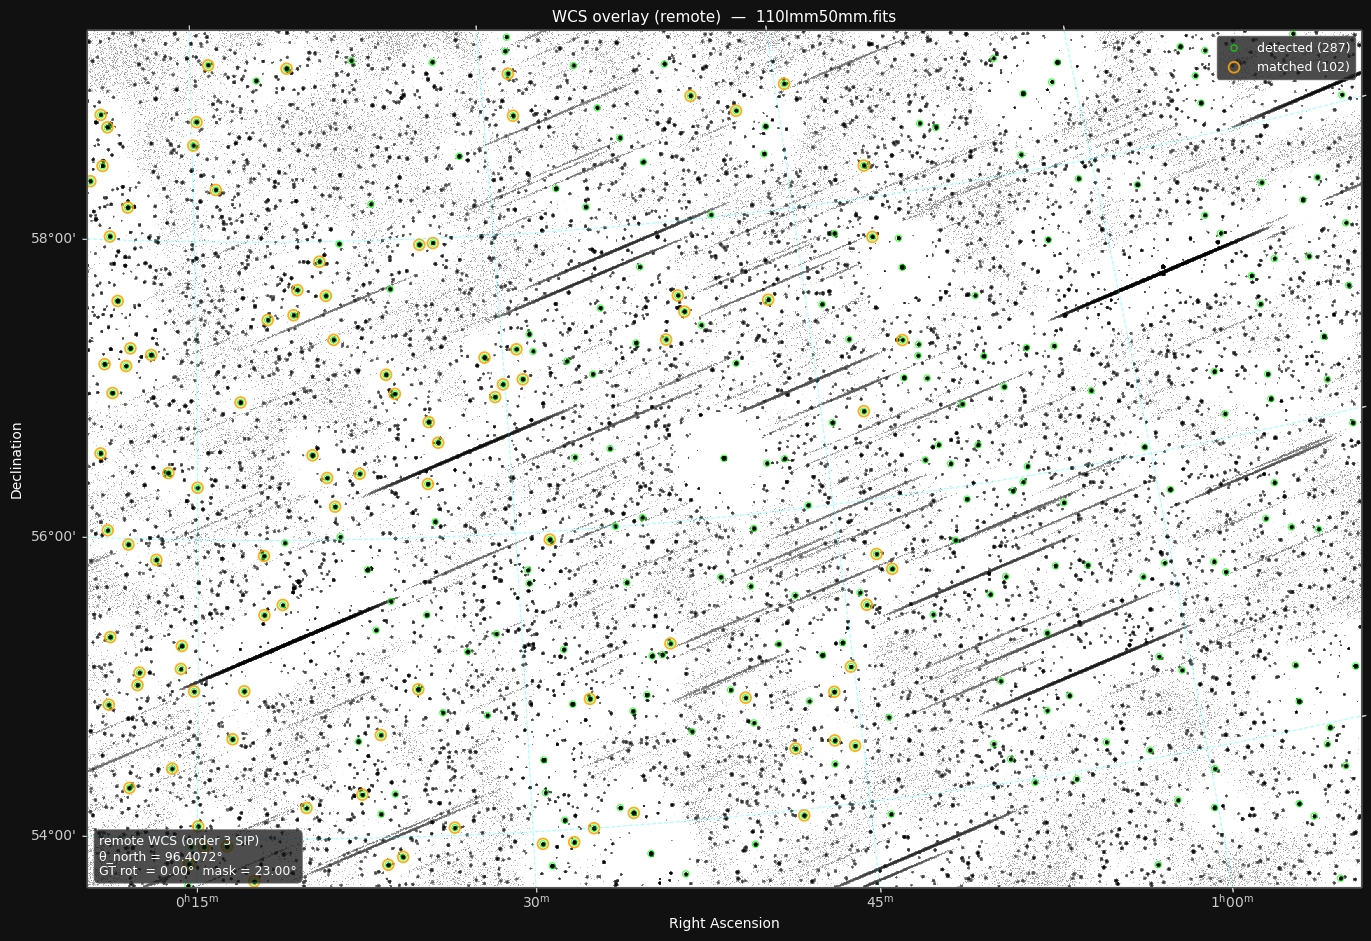

Saved ../outputs/110lmm50mm_test/wcs_overlay_remote.png


In [5]:
# Choose best available WCS for overlay
_best_result = local_result if _local_ok else (remote_result if _remote_ok else None)
_best_label  = 'local' if _local_ok else ('remote' if _remote_ok else None)

if _best_result is None:
    print('No successful solve — cannot plot overlay.')
else:
    _wcs_ov = _make_wcs(_best_result.header)
    from astropy.visualization.wcsaxes import WCSAxes

    fig = plt.figure(figsize=(14, 9.5))
    ax  = fig.add_subplot(111, projection=_wcs_ov)
    ax.imshow(disp, origin='lower', cmap='gray_r', vmin=_dlo, vmax=_dhi,
              aspect='equal', interpolation='nearest')
    ax.coords.grid(True, color='cyan', alpha=0.35, linestyle='--', linewidth=0.8)
    ax.coords['ra'].set_major_formatter('hh:mm')
    ax.coords['dec'].set_major_formatter('dd:mm')
    ax.set_xlabel('Right Ascension'); ax.set_ylabel('Declination')

    # All detected sources
    ax.scatter(all_xs, all_ys, transform=ax.get_transform('pixel'),
               s=20, facecolors='none', edgecolors='lime', linewidths=0.9,
               alpha=0.7, label=f'detected ({len(all_xs)})')

    # Matched sources
    if _best_result.corr_table is not None:
        from extractor.platesolve import _col_array
        _mfx = _col_array(_best_result.corr_table, 'field_x')
        _mfy = _col_array(_best_result.corr_table, 'field_y')
        if len(_mfx) > 0:
            ax.scatter(_mfx, _mfy, transform=ax.get_transform('pixel'),
                       s=60, facecolors='none', edgecolors='orange', linewidths=1.3,
                       alpha=0.9, label=f'matched ({len(_mfx)})')
    elif len(_best_result.matched_x) > 0:
        ax.scatter(_best_result.matched_x, _best_result.matched_y,
                   transform=ax.get_transform('pixel'),
                   s=60, facecolors='none', edgecolors='orange', linewidths=1.3,
                   alpha=0.9, label=f'matched ({len(_best_result.matched_x)})')

    ax.legend(fontsize=9, loc='upper right')
    _best_m = center_wcs_angle_metrics(_wcs_ov, image.shape, compute_east=True)
    _ann = (f'{_best_label} WCS (order 3 SIP)\n'
            f'θ_north = {_best_m.north_angle_deg:.4f}°\n'
            f'GT rot  = {GT_ROT_DEG:.2f}°  mask = {GT_MASK_ANG:.2f}°')
    ax.text(0.01, 0.01, _ann, transform=ax.transAxes,
            fontsize=9, color='white', verticalalignment='bottom',
            bbox=dict(facecolor='#111', alpha=0.75, edgecolor='#555',
                      boxstyle='round,pad=0.4'))
    ax.set_title(f'WCS overlay ({_best_label})  —  {FITS_PATH.name}', fontsize=11)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'wcs_overlay_{_best_label}.png', bbox_inches='tight')
    plt.show()
    print(f'Saved {OUT_DIR}/wcs_overlay_{_best_label}.png')


## Cell 6 — Diagnostics

Compare both WCS solutions against the simulation ground truth and each other.


  DIAGNOSTICS vs GROUND TRUTH
  GT plate scale  : 9.9007 arcsec/px
  GT field centre : RA 10.12724°  Dec 56.53719°
  GT rotation     : 0.000°
  GT mask angle   : 23.000°  (grating orientation, ground truth)

  --- Remote solve ---
    Submitted        : 287 sources
    Matched          : 102 sources
    Plate scale      : 9.8946  (GT 9.9007  Δ -0.0061 "/px)
    GT centre error  : 56.42 px  (558.3")
    θ_north          : 96.4072°
    θ_east           : 5.9137°
    N/E departure    : 180.4935°  (from 90°)
    Expected θ_north : ~90° for ROTDEG=0 (north = +y in pixel space)
    θ_pix=0°  → sky : 96.0265°  east of north
    θ_pix=90° → sky : 6.2984°  east of north
    GT mask 23° sky  → approx θ_pix = -73.41°  (simple inversion)

  --- Local solve ---
    Not available.

  Residual analysis (remote, 102 matched sources):
    RMS  : 9.574 px  (94.73")
    Max  : 27.899 px  (276.05")


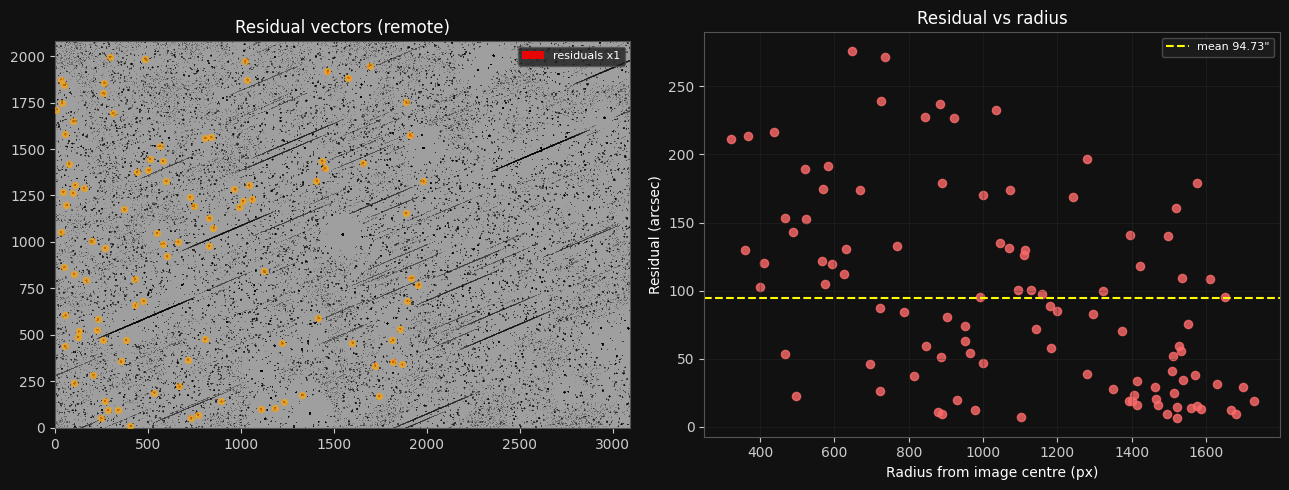


All outputs saved to ../outputs/110lmm50mm_test/


In [6]:
from extractor.wcsangle import pixel_angle_to_sky_angle

print('=' * 65)
print('  DIAGNOSTICS vs GROUND TRUTH')
print('=' * 65)
print(f'  GT plate scale  : {GT_SCALE_ARC:.4f} arcsec/px')
print(f'  GT field centre : RA {GT_RA_DEG:.5f}°  Dec {GT_DEC_DEG:.5f}°')
print(f'  GT rotation     : {GT_ROT_DEG:.3f}°')
print(f'  GT mask angle   : {GT_MASK_ANG:.3f}°  (grating orientation, ground truth)')
print()

for _label, _res, _ok in [('Remote', remote_result, _remote_ok),
                            ('Local',  local_result,  _local_ok)]:
    print(f'  --- {_label} solve ---')
    if not _ok or _res is None:
        print(f'    Not available.')
        print()
        continue

    _wcs = _make_wcs(_res.header)
    _m   = center_wcs_angle_metrics(_wcs, image.shape, compute_east=True)
    from astropy.wcs.utils import proj_plane_pixel_scales as _pps
    _sc  = float(np.mean(np.abs(_pps(_wcs))) * 3600)
    _ne  = abs(angle_diff_deg(_m.east_angle_deg, _m.north_angle_deg) - 90.0)

    # Pixel position of known GT centre
    _cx, _cy = _wcs.world_to_pixel_values(GT_RA_DEG, GT_DEC_DEG)
    _ctr_err = np.hypot(_cx - (nx-1)/2., _cy - (ny-1)/2.)

    print(f'    Submitted        : {len(_res.detected_x)} sources')
    print(f'    Matched          : {len(_res.matched_x)} sources')
    print(f'    Plate scale      : {_sc:.4f}  (GT {GT_SCALE_ARC:.4f}  Δ {_sc-GT_SCALE_ARC:+.4f} "/px)')
    print(f'    GT centre error  : {_ctr_err:.2f} px  ({_ctr_err*_sc:.1f}")')
    print(f'    θ_north          : {_m.north_angle_deg:.4f}°')
    print(f'    θ_east           : {_m.east_angle_deg:.4f}°')
    print(f'    N/E departure    : {_ne:.4f}°  (from 90°)')

    # For GT_ROT_DEG=0, north should point straight up in pixel space
    # θ_north for zero-rotation TAN WCS ≈ 90° (north = +y in pixel)
    # The actual value depends on image flip convention
    print(f'    Expected θ_north : ~90° for ROTDEG=0 (north = +y in pixel space)')

    # Convert a horizontal pixel trace (θ_pix=0°) to sky angle
    _xc, _yc = (nx-1)/2., (ny-1)/2.
    _sky_0   = pixel_angle_to_sky_angle(_wcs, _xc, _yc, 0.0)
    _sky_90  = pixel_angle_to_sky_angle(_wcs, _xc, _yc, 90.0)
    print(f'    θ_pix=0°  → sky : {_sky_0:.4f}°  east of north')
    print(f'    θ_pix=90° → sky : {_sky_90:.4f}°  east of north')

    # What pixel angle corresponds to the 23° grating (sky PA = 23°)?
    # Simple inversion: θ_pix ≈ sky_PA + θ_north  (approximate)
    _approx_grating_pix = (GT_MASK_ANG - _m.north_angle_deg + 180) % 360 - 180
    print(f'    GT mask 23° sky  → approx θ_pix = {_approx_grating_pix:.2f}°  (simple inversion)')
    print()

# Residual analysis (if corr table available)
_res_for_diag = local_result if _local_ok else (remote_result if _remote_ok else None)
_lbl_diag     = 'local' if _local_ok else 'remote'
if _res_for_diag is not None and _res_for_diag.corr_table is not None:
    from extractor.platesolve import get_col
    _corr  = _res_for_diag.corr_table
    _fx    = np.asarray(_corr['field_x'], dtype=float)
    _fy    = np.asarray(_corr['field_y'], dtype=float)
    _ira   = get_col(_corr, 'index_ra')
    _idec  = get_col(_corr, 'index_dec')
    print(f'  Residual analysis ({_lbl_diag}, {len(_fx)} matched sources):')
    if _ira is not None:
        _wcs_d = _make_wcs(_res_for_diag.header)
        _sc_d  = float(np.mean(np.abs(proj_plane_pixel_scales(_wcs_d))) * 3600)
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=FITSFixedWarning)
            _rx, _ry = _wcs_d.world_to_pixel_values(
                np.asarray(_ira, float), np.asarray(_idec, float))
        _res_m = np.hypot(_fx - _rx, _fy - _ry)
        print(f'    RMS  : {_res_m.mean():.3f} px  ({_res_m.mean()*_sc_d:.2f}")')
        print(f'    Max  : {_res_m.max():.3f} px  ({_res_m.max()*_sc_d:.2f}")')

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        _xc_i, _yc_i = (nx-1)/2., (ny-1)/2.
        _rad = np.hypot(_fx - _xc_i, _fy - _yc_i)
        ax = axes[0]
        ax.imshow(disp, origin='lower', cmap='gray_r', vmin=_dlo, vmax=_dhi,
                  aspect='equal', interpolation='nearest', alpha=0.6)
        _scl = max(1.0, 5.0 / max(_res_m.max(), 0.01))
        ax.quiver(_fx, _fy, _fx-_rx, _fy-_ry, color='red',
                  angles='xy', scale_units='xy', scale=1.0/_scl,
                  width=0.003, alpha=0.9, label=f'residuals x{_scl:.0f}')
        ax.scatter(_fx, _fy, s=18, c='orange', alpha=0.6, zorder=4)
        ax.set_xlim(0, nx); ax.set_ylim(0, ny)
        ax.set_title(f'Residual vectors ({_lbl_diag})')
        ax.legend(fontsize=8)
        ax2 = axes[1]
        ax2.scatter(_rad, _res_m * _sc_d, s=35, c='#ff6b6b', alpha=0.8)
        ax2.axhline(_res_m.mean()*_sc_d, color='yellow', ls='--',
                    label=f'mean {_res_m.mean()*_sc_d:.2f}"')
        ax2.set_xlabel('Radius from image centre (px)')
        ax2.set_ylabel('Residual (arcsec)')
        ax2.set_title('Residual vs radius')
        ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f'residuals_{_lbl_diag}.png', bbox_inches='tight')
        plt.show()
    else:
        print('    index_ra/dec not in corr_table — skipping pixel residuals.')
        print('    Columns:', _corr.colnames)

print()
print(f'All outputs saved to {OUT_DIR}/')
